# RNA-Binding Prediction with eCLIP Dataset

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dgruano/elixir_AI4LS_rna_binding/blob/main/rna_binding_eclip.ipynb)

This notebook provides a starter template to fetch, inspect, and analyze the processed **eCLIP dataset** from Hugging Face ([`morrislab/eclip`](https://huggingface.co/datasets/morrislab/eclip), part of [mRNABench](https://github.com/morrislab/mRNABench)).

### Biological Question
Proteins and RNA do not act as independent biomolecules, but orchestrate cellular biology through protein-RNA interactions. Cross-linking experiments (such as eCLIP) followed by RNA sequencing detect transcriptome-wide binding events.

**Could training a machine learning model on this data be able to predict if a given protein binds to a given RNA molecule?**

## 1. Environment Setup & Dependencies

Install the Hugging Face `datasets` library and `pyarrow` to read parquet-formatted biological datasets in Google Colab.

In [ ]:
# Install the notebook dependencies. The project .venv is preferred for local runs.
# Kaggle: enable Internet and a GPU accelerator before running this cell.
%pip install -q datasets pandas pyarrow scikit-learn torch transformers accelerate seaborn matplotlib evo2

Note: you may need to restart the kernel to use updated packages.


## 2. Fetch Dataset from Hugging Face

The `morrislab/eclip` dataset contains eCLIP binding data across human cell lines:
- **`k562`**: Erythroleukemia cell line (~120+ RBPs)
- **`hepg2`**: Hepatocellular carcinoma cell line

We load the dataset using Hugging Face's `datasets` library.

In [2]:
from datasets import Dataset, DatasetDict, load_dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import average_precision_score, confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

# Choose cell line configuration: 'k562' or 'hepg2'
CONFIG = "k562"

print(f"Fetching morrislab/eclip dataset (config: {CONFIG})...")
dataset = load_dataset("morrislab/eclip", CONFIG)
print("Dataset fetched successfully!\n")
print(dataset)

/Users/iseult/gitlab/elixir_AI4LS_rna_binding/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching morrislab/eclip dataset (config: k562)...


Dataset fetched successfully!

DatasetDict({
    train: Dataset({
        features: ['transcript_id', 'gene', 'chromosome', 'sequence', 'cds', 'splice', 'target_AATF', 'target_ABCF1', 'target_AKAP1', 'target_APOBEC3C', 'target_AQR', 'target_BCCIP', 'target_BUD13', 'target_CDC40', 'target_CPEB4', 'target_CPSF6', 'target_CSTF2', 'target_CSTF2T', 'target_DDX21', 'target_DDX24', 'target_DDX3X', 'target_DDX42', 'target_DDX51', 'target_DDX52', 'target_DDX55', 'target_DDX6', 'target_DGCR8', 'target_DHX30', 'target_DKC1', 'target_DROSHA', 'target_EFTUD2', 'target_EIF3D', 'target_EIF3G', 'target_EIF3H', 'target_EIF4G2', 'target_EWSR1', 'target_EXOSC5', 'target_FAM120A', 'target_FASTKD2', 'target_FKBP4', 'target_FMR1', 'target_FXR1', 'target_FXR2', 'target_G3BP1', 'target_GEMIN5', 'target_GNL3', 'target_GPKOW', 'target_GRSF1', 'target_HLTF', 'target_HNRNPA1', 'target_HNRNPC', 'target_HNRNPL', 'target_HNRNPM', 'target_HNRNPU', 'target_HNRNPUL1', 'target_IGF2BP1', 'target_IGF2BP2', 'target_IGF2BP3

## 3. Data Exploration

Convert the training split into a pandas DataFrame to inspect the transcript metadata, RNA sequences, and target binding annotations.

In [3]:
# Convert train split to DataFrame
df = dataset["train"].to_pandas()
print(f"Dataset dimensions: {df.shape[0]} rows x {df.shape[1]} columns\n")

# View metadata columns (transcripts, gene names, chromosomes, sequences)
meta_cols = [c for c in df.columns if not c.startswith("target_")]
print("Sequence metadata columns:", meta_cols)
df[meta_cols].head()


Dataset dimensions: 15717 rows x 128 columns

Sequence metadata columns: ['transcript_id', 'gene', 'chromosome', 'sequence', 'cds', 'splice']


,transcript_id,gene,chromosome,sequence,cds,splice
0,ENST00000433834,CAPZB,1,TCCCTGTACCTGGGGCGCGCCTTCTTTGCAGCCTTTGGGGAGCGAG...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,ENST00000411827,CDC42,1,CGCTGACGTCAGGTGCGTGCCCCTGTCCGGCAGCCGAGGAGACCCC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,ENST00000517138,SCARNA1,1,CAGCACTTGATACTAACCGAGCTGTCTATATCCTAGCCTTGTGTCA...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,ENST00000408612,SNORD99,1,ACTGGTCCAGGATGAAACCTAATTTGAGTGGACATCCATGGATGAG...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,ENST00000410852,RN7SKP91,1,AAATGTGAGGGTGATCTGGCTGTGACATCTGTCACCCTATTGATCG...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


## 4. Explore Available RNA-Binding Proteins (RBPs)

Columns prefixed with `target_` contain binary binding labels for individual RNA-binding proteins profiled by eCLIP.

In [4]:
# List all profiled RBPs
target_cols = [c for c in df.columns if c.startswith("target_")]
rbp_names = [c.replace("target_", "") for c in target_cols]

print(f"Total RBP targets profiled: {len(rbp_names)}")
print("Sample of 20 available RBPs:", rbp_names)

Total RBP targets profiled: 122
Sample of 20 available RBPs: ['AATF', 'ABCF1', 'AKAP1', 'APOBEC3C', 'AQR', 'BCCIP', 'BUD13', 'CDC40', 'CPEB4', 'CPSF6', 'CSTF2', 'CSTF2T', 'DDX21', 'DDX24', 'DDX3X', 'DDX42', 'DDX51', 'DDX52', 'DDX55', 'DDX6', 'DGCR8', 'DHX30', 'DKC1', 'DROSHA', 'EFTUD2', 'EIF3D', 'EIF3G', 'EIF3H', 'EIF4G2', 'EWSR1', 'EXOSC5', 'FAM120A', 'FASTKD2', 'FKBP4', 'FMR1', 'FXR1', 'FXR2', 'G3BP1', 'GEMIN5', 'GNL3', 'GPKOW', 'GRSF1', 'HLTF', 'HNRNPA1', 'HNRNPC', 'HNRNPL', 'HNRNPM', 'HNRNPU', 'HNRNPUL1', 'IGF2BP1', 'IGF2BP2', 'IGF2BP3', 'ILF3', 'KHDRBS1', 'KHSRP', 'LARP4', 'LARP7', 'LIN28B', 'LSM11', 'MATR3', 'METAP2', 'NCBP2', 'NIP7', 'NOL12', 'NOLC1', 'NONO', 'NSUN2', 'PABPC4', 'PABPN1', 'PCBP1', 'PCBP2', 'PPIG', 'PPIL4', 'PRPF4', 'PRPF8', 'PTBP1', 'PUM1', 'PUM2', 'PUS1', 'QKI', 'RBM15', 'RBM22', 'RBM5', 'RPS11', 'SAFB', 'SAFB2', 'SBDS', 'SERBP1', 'SF3A3', 'SF3B1', 'SF3B4', 'SLBP', 'SLTM', 'SMNDC1', 'SND1', 'SRSF1', 'SRSF7', 'SRSF9', 'SSB', 'STAU2', 'SUGP2', 'SUPV3L1', 'TAF15', 

In [5]:
# Inspect the target column structure before selecting the protein of interest.
target_cols = [c for c in df.columns if c.startswith("target_")]
print(f"Target columns: {len(target_cols)}")
print(df[target_cols].notna().all(axis=1).value_counts().to_dict())

Target columns: 122
{True: 15717}


## Heatmap of RNA Binding Protein Hits

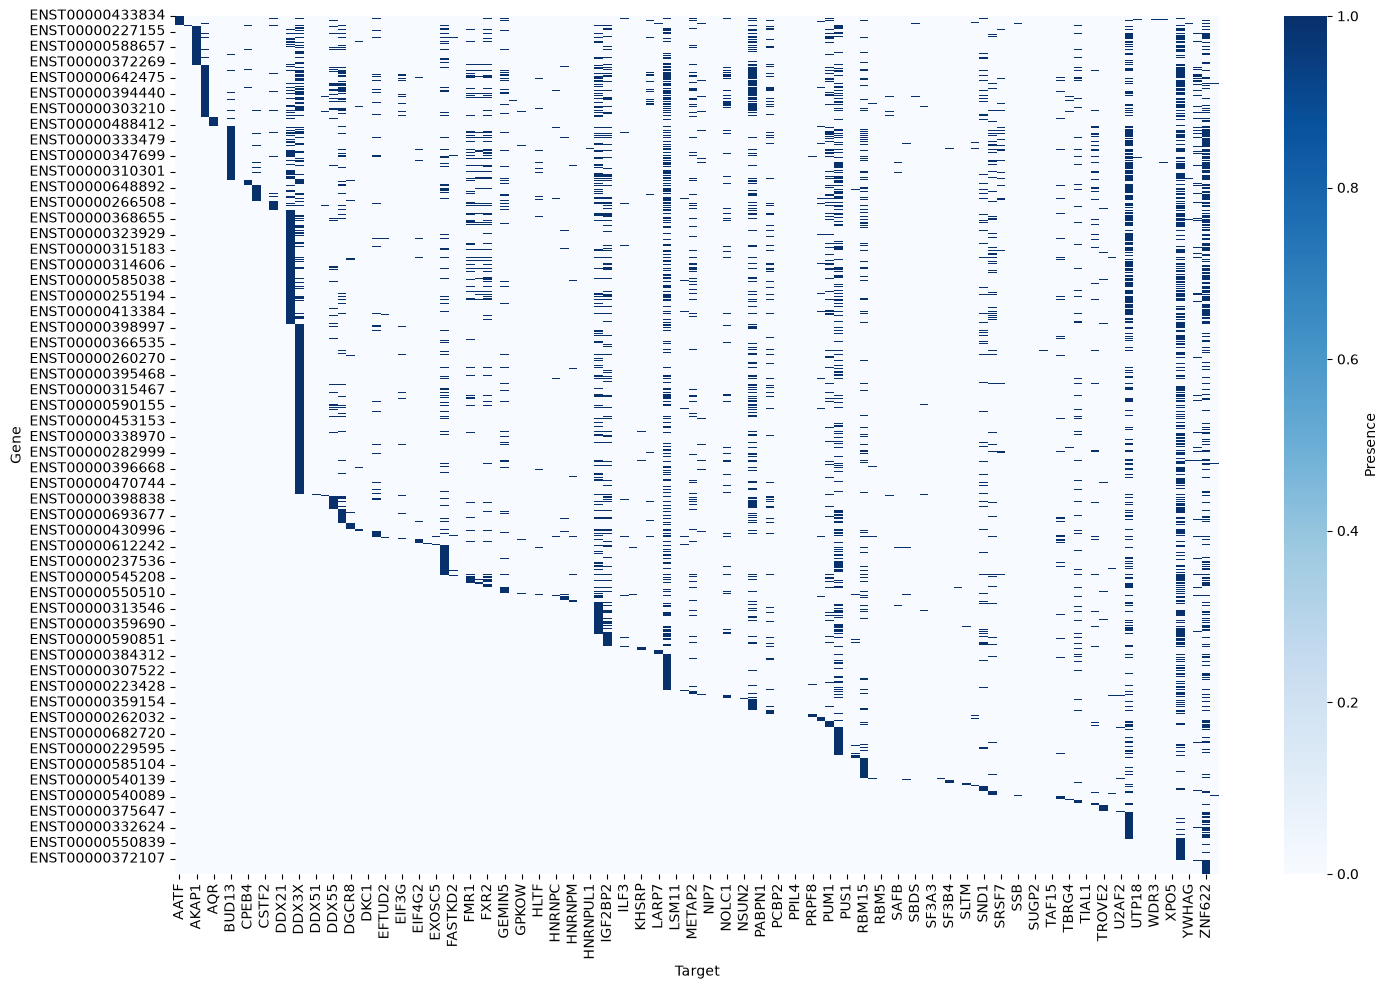

In [6]:
# Get all target columns
target_cols = [c for c in df.columns if c.startswith("target_")]

# Create a matrix of 1/0 values
heatmap_df = df.set_index('transcript_id')[target_cols].astype(int)

# Remove "target_" from the column names
heatmap_df.columns = heatmap_df.columns.str.replace("target_", "", regex=False)

# Plot
plt.figure(figsize=(15, 10))

sns.heatmap(
    heatmap_df,
    cmap="Blues",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Presence"}
)

plt.xlabel("Target")
plt.ylabel("Gene")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
gene = "DKC1"
# Build the binary label only from the protein of interest.
TARGET = f"target_{gene}"
if TARGET not in df.columns:
    raise KeyError(f"{TARGET} is not available in this dataset configuration")
sequences = (
    df.loc[
        df[TARGET].isin([0, 1]),
        ["transcript_id", "sequence", TARGET],
    ]
    .rename(columns={TARGET: "hit"})
    .copy()
)
sequences["hit"] = sequences["hit"].astype("int64")
print(f"{gene} examples: {len(sequences)}")
print(f"{gene} class counts:", sequences["hit"].value_counts().to_dict())
print("Sequence length summary:")
print(sequences["sequence"].str.len().describe())
print(f"Duplicate transcript IDs: {sequences['transcript_id'].duplicated().sum()}")
print(f"Duplicate sequences: {sequences['sequence'].duplicated().sum()}")

HNRNPC examples: 15717
HNRNPC class counts: {0: 15617, 1: 100}


## Split train (60), validation (20) and test (20)
Downsample the number of negatives in the training set

In [ ]:
sequences = sequences[sequences['sequence'].str.len() < 20000]

# Step 1: Separate features (X) and target label (y)
X = sequences[['transcript_id', 'sequence']]
y = sequences['hit']

# Step 2: First split (60% Train, 40% Remaining)
# Stratify on 'y' ensures equal positive class distribution
X_train, X_remain, y_train, y_remain = train_test_split(
    X, y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

# Step 3: Second split (Split the 40% remaining into 50% Val and 50% Test)
# 50% of 40% = 20% of the total dataset for each
X_val, X_test, y_val, y_test = train_test_split(
    X_remain, y_remain,
    test_size=0.50,
    stratify=y_remain,
    random_state=42
)

# Step 4: Downsample training negatives to a 5% positive ratio.
# Validation and test remain untouched so their metrics reflect the real distribution.
positive_ratio = 0.05
pos_mask = y_train == 1
neg_mask = y_train == 0
X_train_pos = X_train[pos_mask]
y_train_pos = y_train[pos_mask]
X_train_neg = X_train[neg_mask]
y_train_neg = y_train[neg_mask]

num_pos = len(y_train_pos)
num_neg_needed = min(
    len(y_train_neg),
    int(num_pos * (1 - positive_ratio) / positive_ratio),
)
X_train_neg_downsampled = X_train_neg.sample(n=num_neg_needed, random_state=42)
y_train_neg_downsampled = y_train_neg.loc[X_train_neg_downsampled.index]

X_train = pd.concat([X_train_pos, X_train_neg_downsampled])
y_train = pd.concat([y_train_pos, y_train_neg_downsampled])
shuffle_idx = np.random.default_rng(seed=42).permutation(len(y_train))
X_train = X_train.iloc[shuffle_idx]
y_train = y_train.iloc[shuffle_idx]

# Verify the effective distributions used by training and evaluation.
for name, y_set in zip(['Train', 'Val', 'Test'], [y_train, y_val, y_test]):
    pos_ratio = y_set.mean()
    print(f"{name} set size: {len(y_set)} | Positive class ratio: {pos_ratio:.4f}")


Train set size: 1200 | Positive class ratio: 0.0500
Val set size: 3140 | Positive class ratio: 0.0064
Test set size: 3140 | Positive class ratio: 0.0064


In [ ]:
set_seed(42)
import math
import os
from collections import defaultdict
from torch import nn

if not torch.cuda.is_available():
    raise RuntimeError("Evo 2 requires a CUDA-enabled Kaggle GPU. Enable GPU acceleration first.")

device = torch.device("cuda")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 2**30:.1f} GiB")
import json

from evo2 import Evo2

MODEL_NAME = "evo2_1b_base"
evo2 = Evo2(MODEL_NAME)
evo2.eval()
evo2 = evo2.to(device)
for parameter in evo2.parameters():
    parameter.requires_grad_(False)

print(f"Loaded {MODEL_NAME} with {sum(p.numel() for p in evo2.parameters()) / 1e9:.2f}B parameters")

def split_equal_chunks(sequence, max_length):
    """Split a normalized sequence into chunks with lengths differing by at most one base."""
    chunk_count = max(1, math.ceil(len(sequence) / max_length))
    boundaries = np.linspace(0, len(sequence), chunk_count + 1, dtype=int)
    return [sequence[start:end] for start, end in zip(boundaries[:-1], boundaries[1:])]

def expand_chunks(frame, max_length):
    rows = []
    for source_index, row in frame.iterrows():
        chunks = split_equal_chunks(row["sequence"], max_length)
        for chunk_index, chunk in enumerate(chunks):
            start = sum(len(item) for item in chunks[:chunk_index])
            rows.append({
                "source_index": int(source_index),
                "transcript_id": row["transcript_id"],
                "chunk_index": chunk_index,
                "chunk_count": len(chunks),
                "start": start,
                "end": start + len(chunk),
                "sequence": chunk,
                "label": int(row["label"]),
            })
    return pd.DataFrame(rows)

def encode_sequence(sequence):
    token_ids = evo2.tokenizer.tokenize(sequence)
    return torch.tensor(token_ids, dtype=torch.long, device=device).unsqueeze(0)

@torch.no_grad()
def extract_embedding(sequence):
    input_ids = encode_sequence(sequence)
    _, embeddings = evo2(input_ids, return_embeddings=True)
    if embeddings.ndim == 3:
        return embeddings.mean(dim=1).squeeze(0).float().cpu()
    return embeddings.squeeze(0).float().cpu()

SMOKE_SEQUENCE = "ACGT" * 32
smoke_embedding = extract_embedding(SMOKE_SEQUENCE)
print(f"Smoke-test embedding shape: {tuple(smoke_embedding.shape)}")

# Splits happen before chunk expansion so chunks from one transcript cannot leak across splits.
train_frame = X_train.copy()
train_frame["label"] = y_train.astype("int64")
val_frame = X_val.copy()
val_frame["label"] = y_val.astype("int64")
test_frame = X_test.copy()
test_frame["label"] = y_test.astype("int64")

MODEL_CONTEXT = int(getattr(evo2, "max_seq_len", getattr(evo2, "context_length", 8192)))
CHUNK_LENGTH = min(MODEL_CONTEXT, 8192)
if CHUNK_LENGTH > MODEL_CONTEXT:
    raise ValueError("CHUNK_LENGTH must not exceed the Evo 2 context length")

train_chunks = expand_chunks(train_frame, CHUNK_LENGTH)
val_chunks = expand_chunks(val_frame, CHUNK_LENGTH)
test_chunks = expand_chunks(test_frame, CHUNK_LENGTH)
print(f"Chunk counts: train={len(train_chunks)}, val={len(val_chunks)}, test={len(test_chunks)}")
print(f"Maximum chunk length: {max(len(seq) for seq in train_chunks['sequence'])}")

def add_embeddings(frame, name):
    embeddings = []
    for sequence in frame["sequence"]:
        embeddings.append(extract_embedding(sequence))
    result = torch.stack(embeddings)
    print(f"{name} embeddings: {tuple(result.shape)}")
    return result

train_embeddings = add_embeddings(train_chunks, "Train")
val_embeddings = add_embeddings(val_chunks, "Validation")
test_embeddings = add_embeddings(test_chunks, "Test")

embedding_dim = train_embeddings.shape[1]
classifier = nn.Sequential(
    nn.LayerNorm(embedding_dim),
    nn.Linear(embedding_dim, 1),
).to(device)

train_labels = torch.tensor(train_chunks["label"].to_numpy(), dtype=torch.float32, device=device)
val_labels = torch.tensor(val_chunks["label"].to_numpy(), dtype=torch.float32, device=device)
test_labels = torch.tensor(test_chunks["label"].to_numpy(), dtype=torch.float32, device=device)
train_features = train_embeddings.to(device)
val_features = val_embeddings.to(device)
test_features = test_embeddings.to(device)
positive_weight = (train_labels == 0).sum() / (train_labels == 1).sum().clamp_min(1)
loss_function = nn.BCEWithLogitsLoss(pos_weight=positive_weight)
optimizer = torch.optim.AdamW(classifier.parameters(), lr=1e-3, weight_decay=1e-2)

def train_classifier(epochs=30):
    classifier.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        logits = classifier(train_features).squeeze(-1)
        loss = loss_function(logits, train_labels)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1:02d} | weighted loss {loss.item():.4f}")

train_classifier()

@torch.no_grad()
def chunk_probabilities(features):
    classifier.eval()
    return torch.sigmoid(classifier(features).squeeze(-1)).cpu().numpy()

def aggregate_transcripts(chunks, probabilities, method="max"):
    grouped = defaultdict(list)
    for transcript_id, probability in zip(chunks["transcript_id"], probabilities):
        grouped[transcript_id].append(float(probability))
    if method == "mean":
        return {key: float(np.mean(values)) for key, values in grouped.items()}
    if method == "top_k":
        return {key: float(np.mean(sorted(values, reverse=True)[:max(1, len(values) // 4)])) for key, values in grouped.items()}
    return {key: float(np.max(values)) for key, values in grouped.items()}

def frame_scores(frame, chunks, probabilities, method):
    scores = aggregate_transcripts(chunks, probabilities, method)
    return np.array([scores[transcript_id] for transcript_id in frame["transcript_id"]])

train_probabilities = chunk_probabilities(train_features)
val_probabilities = chunk_probabilities(val_features)
test_probabilities = chunk_probabilities(test_features)
pooling_methods = ["mean", "max", "top_k"]
pooling_scores = {}
for method in pooling_methods:
    validation_scores = frame_scores(val_frame, val_chunks, val_probabilities, method)
    pooling_scores[method] = average_precision_score(y_val, validation_scores)
    print(f"Validation transcript PR-AUC ({method}): {pooling_scores[method]:.4f}")
POOLING = max(pooling_scores, key=pooling_scores.get)
print(f"Selected pooling method: {POOLING}")

validation_scores = frame_scores(val_frame, val_chunks, val_probabilities, POOLING)
test_scores = frame_scores(test_frame, test_chunks, test_probabilities, POOLING)
thresholds = np.unique(np.concatenate(([0.0, 0.5, 1.0], validation_scores)))
threshold = max(thresholds, key=lambda value: f1_score(y_val, validation_scores >= value, zero_division=0))
test_predictions = (test_scores >= threshold).astype(int)
print(f"Validation threshold selected for F1: {threshold:.4f}")
print(f"Test PR-AUC: {average_precision_score(y_test, test_scores):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, test_scores):.4f}")
print(f"Test F1: {f1_score(y_test, test_predictions, zero_division=0):.4f}")

torch.save(classifier.state_dict(), "./evo2_dkc1_classifier.pt")
with open("./evo2_dkc1_metadata.json", "w") as metadata_file:
    json.dump({
        "model_name": MODEL_NAME,
        "target": gene,
        "chunk_length": CHUNK_LENGTH,
        "pooling": POOLING,
        "threshold": float(threshold),
        "normalization": "uppercase RNA with U converted to T",
    }, metadata_file, indent=2)
print("Classifier and metadata saved to /kaggle/working-compatible relative paths.")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 53700.48it/s]
[transformers] DNABertForSequenceClassification LOAD REPORT from: zhihan1996/DNA_bert_6
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the 

Epoch,Training Loss,Validation Loss,Pr Auc,F1
1,0.260994,0.036754,0.002866,0.000000
2,0.203876,0.056372,0.002866,0.000000
3,0.218835,0.028851,0.002870,0.000000
4,0.226297,0.043914,0.002870,0.000000
5,0.180491,0.055318,0.002870,0.000000
6,0.225751,0.032248,0.002866,0.000000
7,0.214453,0.050921,0.002866,0.000000
8,0.210029,0.048351,0.002866,0.000000
9,0.181265,0.046455,0.002870,0.000000
10,0.178660,0.037752,0.002866,0.000000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.94it/s]
/Users/iseult/gitlab/elixir_AI4LS_rna_binding/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.95it/s]
/Users/iseult/gitlab/elixir_AI4LS_rna_binding/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.89it/s]
/Users/iseult/gitlab/elixir_AI4LS_rna_binding/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model sh

Training Loss,Validation Loss,Epoch,Pr Auc,F1
0.202272,0.028851,20,0.002870,0.000000


Test metrics: {'eval_loss': 0.028851019218564034, 'eval_pr_auc': 0.0028698979591836736, 'eval_f1': 0.0}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.84it/s]

Training complete! Model saved.


## 5. Model Quality Control

The following plots summarize transcript-level Evo 2 classification performance.

In [ ]:
def plot_confusion_matrix(test_labels, test_predictions):
    """Plot transcript-level confusion counts at the validation-selected threshold."""
    tn, fp, fn, tp = confusion_matrix(test_labels, test_predictions, labels=[0, 1]).ravel()
    print(f"TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}")
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        [[tn, fp], [fn, tp]],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predicted 0", "Predicted 1"],
        yticklabels=["Actual 0", "Actual 1"],
    )
    plt.title("Transcript-Level Test Confusion Matrix")
    plt.xlabel("Prediction")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(np.asarray(y_test).astype(int), test_predictions)
false_positive_rate, true_positive_rate, _ = roc_curve(y_test, test_scores)
auroc = roc_auc_score(y_test, test_scores)
plt.figure(figsize=(7, 6))
plt.plot(false_positive_rate, true_positive_rate, label=f"AUROC = {auroc:.3f}", color="tab:green")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Transcript-Level Test AUROC Curve")
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
print(f"Test prevalence: {np.mean(y_test):.4f}")
print(f"Test average precision: {average_precision_score(y_test, test_scores):.4f}")
print(f"Test AUROC: {auroc:.4f}")